# Music Analysis with Pandas

Billboard + Spotify data from Kaggle   
- | https://www.kaggle.com/datasets/ludmin/billboard | 
- | https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024  | 
- | https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset |

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load & Combine Data

In [12]:
hot100 = pd.read_csv('datasets/hot100.csv', low_memory=False)
billboard200 = pd.read_csv('datasets/billboard200.csv', low_memory=False)
streaming = pd.read_csv('datasets/streaming.csv')
spotify = pd.read_csv('datasets/SpotifyTrackDataset.csv')

hot100['chart'] = 'Hot100'
billboard200['chart'] = 'Billboard200'
streaming['chart'] = 'Streaming'

charts = pd.concat([hot100, billboard200, streaming], ignore_index=True)

print(f'Total rows: {len(charts)}')
charts.head()

Total rows: 1040477


,Date,Song,Artist,Rank,Last Week,Peak Position,Weeks in Charts,Image URL,chart
0,1958-07-30,Poor Little Fool,Ricky Nelson,1,-,1,1,NaN,Hot100
1,1958-07-30,Patricia,Perez Prado And His Orchestra,2,-,2,1,NaN,Hot100
2,1958-07-30,Splish Splash,Bobby Darin,3,-,3,1,NaN,Hot100
3,1958-07-30,Hard Headed Woman,Elvis Presley With The Jordanaires,4,-,4,1,https://charts-static.billboard.com/img/1958/0...,Hot100
4,1958-07-30,When,Kalin Twins,5,-,5,1,NaN,Hot100


## 2. Clean Data

In [13]:
charts['Date'] = pd.to_datetime(charts['Date'], errors='coerce')
charts['year'] = charts['Date'].dt.year
charts['Rank'] = pd.to_numeric(charts['Rank'], errors='coerce')
charts = charts.drop_duplicates(subset=['Song', 'Artist', 'Date', 'chart'])

print(f'After cleaning: {len(charts)} rows')
charts.head()

After cleaning: 1040408 rows


,Date,Song,Artist,Rank,Last Week,Peak Position,Weeks in Charts,Image URL,chart,year
0,1958-07-30,Poor Little Fool,Ricky Nelson,1,-,1,1,NaN,Hot100,1958
1,1958-07-30,Patricia,Perez Prado And His Orchestra,2,-,2,1,NaN,Hot100,1958
2,1958-07-30,Splish Splash,Bobby Darin,3,-,3,1,NaN,Hot100,1958
3,1958-07-30,Hard Headed Woman,Elvis Presley With The Jordanaires,4,-,4,1,https://charts-static.billboard.com/img/1958/0...,Hot100,1958
4,1958-07-30,When,Kalin Twins,5,-,5,1,NaN,Hot100,1958


## 3. Summary by Chart Type

In [14]:
summary = charts.groupby('chart').agg(
    total=('Song', 'count'),
    artists=('Artist', 'nunique'),
    avg_rank=('Rank', 'mean')
)
summary

,total,artists,avg_rank
chart,,,
Billboard200,649013,10403,99.368906
Hot100,355645,11266,50.501090
Streaming,35750,1861,25.500000


## 4. Top Artists

In [15]:
top_artists = charts[charts['chart'] == 'Hot100']['Artist'].value_counts().head(10)
top_artists

Artist
Taylor Swift     1766
Drake            1147
Morgan Wallen    1093
Elton John        889
Madonna           857
Kenny Chesney     797
Tim McGraw        749
Keith Urban       674
Jason Aldean      672
Stevie Wonder     659
Name: count, dtype: int64

## 5. Top Spotify Streamed Artists in 2024

In [16]:
most_streamed = pd.read_csv('datasets/MostStreamedSpotify2024.csv', encoding='latin-1')

most_streamed['Spotify Streams'] = (
    most_streamed['Spotify Streams']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

spotify_artists = most_streamed.groupby('Artist')['Spotify Streams'].sum().sort_values(ascending=False).head(10)
spotify_artists

Artist
Bad Bunny         3.705483e+10
The Weeknd        3.694854e+10
Drake             3.496216e+10
Taylor Swift      3.447077e+10
Post Malone       2.613747e+10
Ed Sheeran        2.401490e+10
Ariana Grande     2.346499e+10
MUSIC LAB JPN     2.286669e+10
Olivia Rodrigo    1.972922e+10
Eminem            1.887888e+10
Name: Spotify Streams, dtype: float64

## 6. Most Persistent Songs

In [17]:
charts['Weeks in Charts'] = pd.to_numeric(
    charts['Weeks in Charts'].astype(str).str.replace(',', '', regex=False), 
    errors='coerce'
)

top_weeks = charts.sort_values('Weeks in Charts', ascending=False).head(10)
top_weeks[['Song', 'Artist', 'chart', 'Weeks in Charts']]

,Song,Artist,chart,Weeks in Charts
997293,The Dark Side Of The Moon,Pink Floyd,Billboard200,996.0
997040,The Dark Side Of The Moon,Pink Floyd,Billboard200,995.0
996848,The Dark Side Of The Moon,Pink Floyd,Billboard200,994.0
996698,The Dark Side Of The Moon,Pink Floyd,Billboard200,993.0
996487,The Dark Side Of The Moon,Pink Floyd,Billboard200,992.0
995119,The Dark Side Of The Moon,Pink Floyd,Billboard200,991.0
979593,The Dark Side Of The Moon,Pink Floyd,Billboard200,990.0
979280,The Dark Side Of The Moon,Pink Floyd,Billboard200,989.0
976281,The Dark Side Of The Moon,Pink Floyd,Billboard200,988.0
976040,The Dark Side Of The Moon,Pink Floyd,Billboard200,987.0


## 7. Yearly Activity

In [18]:
year_counts = charts['year'].value_counts().sort_index()
print('Chart activity by year:')
print(year_counts)

Chart activity by year:
year
1958     2291
1959     5200
1960     5199
1961     5194
1962     5200
        ...  
2022    18200
2023    18200
2024    18200
2025    18550
2026    13300
Name: count, Length: 69, dtype: int64


## 8. Top 10 Songs by Best Rank

In [19]:
top_ranked = charts.nsmallest(10, 'Rank')[['Song', 'Artist', 'chart', 'Rank', 'year']]
top_ranked

,Song,Artist,chart,Rank,year
0,Poor Little Fool,Ricky Nelson,Hot100,1,1958
97,Poor Little Fool,Ricky Nelson,Hot100,1,1958
195,Nel Blu Dipinto Di Blu (Volare),Domenico Modugno,Hot100,1,1958
292,Little Star,The Elegants,Hot100,1,1958
391,Nel Blu Dipinto Di Blu (Volare),Domenico Modugno,Hot100,1,1958
491,Nel Blu Dipinto Di Blu (Volare),Domenico Modugno,Hot100,1,1958
591,Nel Blu Dipinto Di Blu (Volare),Domenico Modugno,Hot100,1,1958
691,Nel Blu Dipinto Di Blu (Volare),Domenico Modugno,Hot100,1,1958
791,It's All In The Game,Tommy Edwards,Hot100,1,1958
891,It's All In The Game,Tommy Edwards,Hot100,1,1958


## 9. Graphs & Save

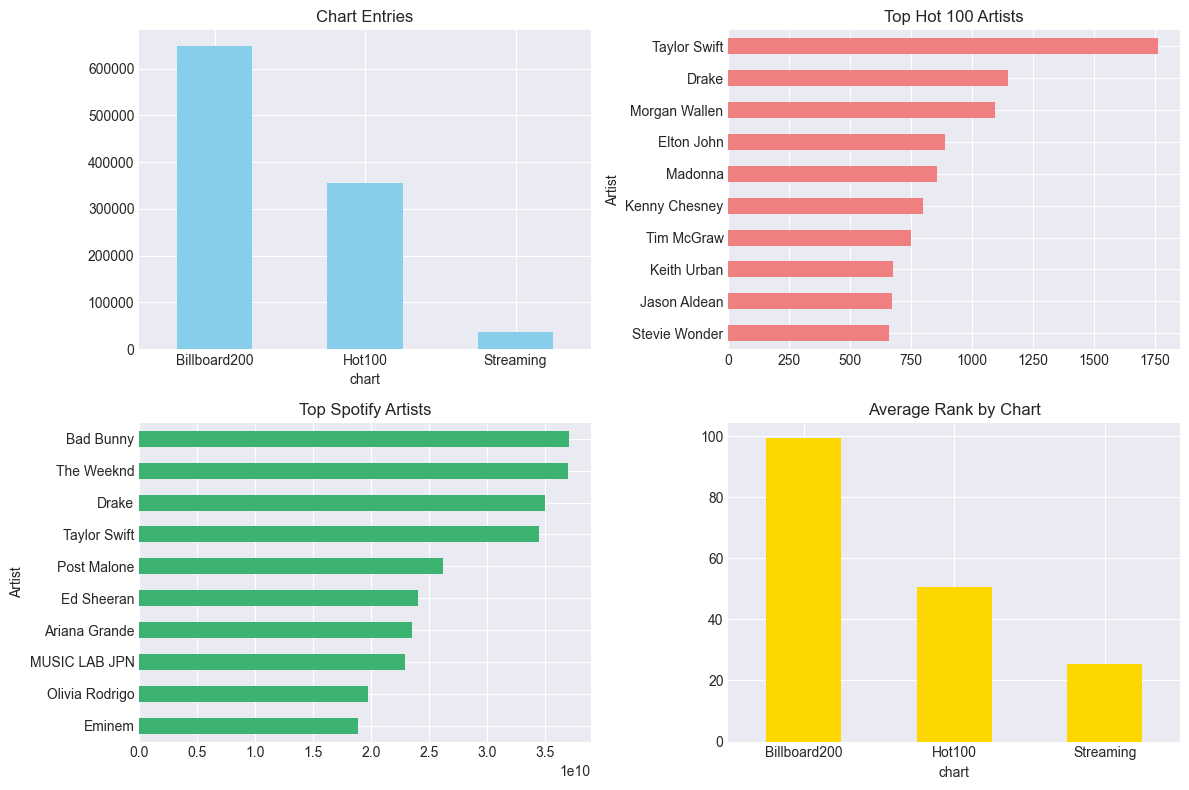

Saved cleaned_charts.csv


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

charts['chart'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue', title='Chart Entries')
axes[0,0].tick_params(axis='x', rotation=0)

top_artists.plot(kind='barh', ax=axes[0,1], color='lightcoral', title='Top Hot 100 Artists')
axes[0,1].invert_yaxis()

spotify_artists.plot(kind='barh', ax=axes[1,0], color='mediumseagreen', title='Top Spotify Artists')
axes[1,0].invert_yaxis()

summary['avg_rank'].plot(kind='bar', ax=axes[1,1], color='gold', title='Average Rank by Chart')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

charts.to_csv('cleaned_charts.csv', index=False)
print('Saved cleaned_charts.csv')

cleaned_charts.csv gets saved to the workspace.